In [ ]:
#Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#!pip install scikit-learn

In [ ]:
# Install libraries
from pathlib import Path
import pandas as pd
import os.path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [ ]:
# Drive Path (Hayden)
image_dir = Path('/content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images')

In [ ]:
# Get images
filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

images = pd.concat([filepaths, labels], axis=1)

# Get all images.
num_samples = len(images)
image_df = images.sample(n=num_samples, random_state=1).reset_index(drop=True)

print(f"Selected {len(image_df)} images for processing.")

Selected 101014 images for processing.


In [ ]:
# Remove labels to desired size
label_counts = image_df['Label'].value_counts()
num_classes_to_remove = int(len(label_counts) * 0.8)

# Get the labels with the lowest counts
labels_to_remove = label_counts.nsmallest(num_classes_to_remove).index.tolist()

# Filter image_df to exclude these labels
filtered_image_df = image_df[~image_df['Label'].isin(labels_to_remove)]

print(f"Original number of images: {len(image_df)}")
print(f"Number of classes removed: {num_classes_to_remove}")
print(f"Number of classes kept: {101-num_classes_to_remove}")
print(f"New total count of images after filtering: {len(filtered_image_df)}")

image_df = filtered_image_df.copy()

Original number of images: 101014
Number of classes removed: 80
Number of classes kept: 21
New total count of images after filtering: 21014


In [ ]:
print("Labels kept:", image_df['Label'].unique())

Labels kept: ['paella' 'samosa' 'caesar_salad' 'baby_back_ribs' 'chocolate_cake'
 'lobster_roll_sandwich' 'crab_cakes' 'deviled_eggs' 'omelette' 'churros'
 'grilled_salmon' 'ceviche' 'cheesecake' 'hot_dog' 'takoyaki'
 'french_onion_soup' 'tiramisu' 'seaweed_salad' 'fried_calamari'
 'pork_chop' 'pad_thai']


In [ ]:
# Create dataset for LLM to intake
test_df = image_df.groupby('Label').sample(n=5, random_state=42).reset_index(drop=True)

print(f"Number of images in the testing dataset: {len(test_df)}")
print("First 5 rows of the testing dataframe:")
display(test_df.head())


Number of images in the testing dataset: 105
First 5 rows of the testing dataframe:


,Filepath,Label
0,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,baby_back_ribs
1,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,baby_back_ribs
2,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,baby_back_ribs
3,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,baby_back_ribs
4,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,baby_back_ribs


In [ ]:
# Check the distribution of labels in the testing dataframe
print("Label distribution in the testing dataframe:")
display(test_df['Label'].value_counts())


Label distribution in the testing dataframe:


,count
Label,
baby_back_ribs,5
caesar_salad,5
ceviche,5
cheesecake,5
chocolate_cake,5
churros,5
crab_cakes,5
deviled_eggs,5
french_onion_soup,5


In [ ]:
# Shuffle the DataFrame rows
shuffled_df = test_df.sample(frac=1)

In [ ]:
# Remove labels
X_test = shuffled_df['Filepath']
Y_test = shuffled_df['Label']

display(X_test.head())

display(Y_test.head())

,Filepath
40,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...
57,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...
17,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...
52,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...
72,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...


,Label
40,french_onion_soup
57,hot_dog
17,cheesecake
52,grilled_salmon
72,pad_thai


## Gemini Model (Classification)


In [ ]:
#!pip install -q -U google-generativeai

In [ ]:
import google.generativeai as genai

In [ ]:
# Set up Secret AI Key
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

version = 'models/gemini-2.5-flash-lite'
model = genai.GenerativeModel(version)

In [ ]:
from PIL import Image
import io

In [ ]:
food_options = ['paella', 'samosa', 'caesar_salad', 'baby_back_ribs', 'chocolate_cake',
                'lobster_roll_sandwich', 'crab_cakes', 'deviled_eggs', 'omelette', 'churros',
                'grilled_salmon', 'ceviche', 'cheesecake', 'hot_dog', 'takoyaki',
                'french_onion_soup', 'tiramisu', 'seaweed_salad', 'fried_calamari',
                'pork_chop', 'pad_thai']

In [ ]:
# !{sys.executable} -m pip install tenacity

In [ ]:
import time
import tenacity
import requests
import sys
from tenacity import retry, wait_exponential, stop_after_attempt, stop_after_delay

In [ ]:
# create function to prompt llm with a wait mechanic
@retry(wait=wait_exponential(multiplier=1, min=4, max=10), stop=stop_after_attempt(5), reraise=True, retry=(tenacity.retry_if_exception_type(Exception) | tenacity.retry_if_exception_type(requests.exceptions.RequestException)))
def classify_image_with_gemini2(image_path, model, options):
    try:
        img = Image.open(image_path)
        img.thumbnail((224, 224), Image.Resampling.LANCZOS)

        time.sleep(1)

        prompt = f"What food item is in this image? Choose only one from the following list and provide only the name of the food: {', '.join(options)}"
        response = model.generate_content([prompt, img])
        # Attempt to clean the response to get just the label
        classified_label = response.text.strip().lower()
        # Simple check if the classified label is in our options list, or a similar variation
        for option in options:
            if option.replace('_', ' ') in classified_label.replace('_', ' '):
                return option
        return classified_label
    except Exception as e:
        print(f"Error classifying {image_path}: {e}")
        raise # Re-raise the exception to trigger retry

In [ ]:
# Initialize predictions list
predictions = []
# Complete 10 at a time
chunk_size = 10

# Iterate through each image in X_test in chunks
for i in range(0, len(X_test), chunk_size):
    image_chunk = X_test[i:i + chunk_size]
    print(f"\nProcessing chunk {int(i/chunk_size) + 1} (images {i+1} to {min(i + chunk_size, len(X_test))}/{len(X_test)})...")
    for j, image_path in enumerate(image_chunk):
        print(f"Classifying image {i+j+1}/{len(X_test)}: {image_path}")
        try:
            prediction = classify_image_with_gemini2(image_path, model, food_options)
            predictions.append(prediction)
        except Exception as e:
            print(f"Skipping image {image_path} due to repeated errors after retries: {e}")
            predictions.append("Error") # Append "Error" if all retries fail for an image

print("\nClassification complete!")
print("First 5 predictions:", predictions[:5])

Classifying image 1/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/french_onion_soup/3622059.jpg
Classifying image 2/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/hot_dog/233179.jpg
Classifying image 3/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/cheesecake/509947.jpg
Classifying image 4/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/grilled_salmon/3130214.jpg
Classifying image 5/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/pad_thai/3372968.jpg
Classifying image 6/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/churros/1141049.jpg
Classifying image 7/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/deviled_eggs/1171668.jpg
Classifying image 8/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/pork_chop/942195.jpg
Classifying image 9/105: /content/drive/MyDrive

Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/lobster_roll_sandwich/2743428.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 58.215023953s.
Classifying image 19/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/tiramisu/2362725.jpg
Classifying image 20/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/pork_chop/3076558.jpg
Classifying image 21/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3

Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/baby_back_ribs/1299678.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 9.248426124s.


Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/baby_back_ribs/1299678.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 4.01552723s.


Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/baby_back_ribs/1299678.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 58.78966942s.
Classifying image 36/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/churros/1547922.jpg
Classifying image 37/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/omelette/1675150.jpg
Classifying image 38/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data

...

Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/grilled_salmon/3800701.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 95.560935ms.
Classifying image 88/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/cheesecake/2506844.jpg
Classifying image 89/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/deviled_eggs/3303088.jpg
Classifying image 90/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Dat

Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/french_onion_soup/3031207.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 17.542780556s.
Classifying image 104/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/omelette/3902995.jpg


Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/omelette/3902995.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 9.765669045s.
Classifying image 105/105: /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/tiramisu/511137.jpg


Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/tiramisu/511137.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 2.391901731s.


Error classifying /content/drive/MyDrive/Ai_and_Deep_Learning/Project 3 Data/Data/images/tiramisu/511137.jpg: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-2.5-flash-lite
Please retry in 57.227979802s.
First 5 predictions: ['french_onion_soup', 'hot_dog', 'cheesecake', 'grilled_salmon', 'pad_thai']


In [ ]:
#Output example
LLM_Output = pd.DataFrame(predictions, columns=["LLM_Output"])
LLM_Output.head()

,LLM_Output
0,french_onion_soup
1,hot_dog
2,cheesecake
3,grilled_salmon
4,pad_thai


In [ ]:
InputDF = shuffled_df.reset_index(drop=True)

In [ ]:
# Get original label
input_df = pd.concat([InputDF, LLM_Output], axis=1)
input_df.head()

,Filepath,Label,LLM_Output
0,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,french_onion_soup,french_onion_soup
1,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,hot_dog,hot_dog
2,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,cheesecake,cheesecake
3,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,grilled_salmon,grilled_salmon
4,/content/drive/MyDrive/Ai_and_Deep_Learning/Pr...,pad_thai,pad_thai


In [ ]:
# Get accuracy score
accuracy = (input_df['Label'] == input_df['LLM_Output']).mean() * 100
print(f"Accuracy of LLM predictions: {accuracy:.2f}%")

Accuracy of LLM predictions: 98.10%


In [ ]:
score = accuracy_score(input_df[['Label']], input_df[['LLM_Output']])
print(f"Accuracy of LLM predictions: {score:.2f}")

Accuracy of LLM predictions: 0.98


## AI Calorie Testing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [ ]:
# Set up Secret AI Key
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

version = 'models/gemini-2.5-flash-lite'
model = genai.GenerativeModel(version)

In [ ]:
#import dataset
recipe_data = pd.read_csv('recipes_with_images.csv')
recipe_data.head()

,RecipeId,Barcode,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,...,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions,extracted_image_urls,extracted_ingredients
0,39.0,*39*,Biryani,1567.0,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,...,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and...",['https://img.sndimg.com/food/image/upload/w_5...,"['saffron', 'milk', 'hot green chili peppers',..."
1,40.0,*40*,Best Lemonade,1566.0,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,...,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ...",['https://img.sndimg.com/food/image/upload/w_5...,"['sugar', 'lemons, rind of', 'lemon, zest of',..."
2,41.0,*41*,Carina's Tofu-Vegetable Kebabs,1586.0,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,...,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc...",['https://img.sndimg.com/food/image/upload/w_5...,"['extra firm tofu', 'eggplant', 'zucchini', 'm..."
3,47.0,*47*,Butter Pecan Cookies,1573.0,benluc,PT9M,PT55M,PT1H4M,1999-09-07T09:01:00Z,Make and share this Butter Pecan Cookies recip...,...,15.0,4.5,0.6,1.6,0.8,NaN,84 cookies,"c(""Preheat oven to 350 degrees."", ""Cream butte...",['https://img.sndimg.com/food/image/upload/w_5...,"['butter', 'brown sugar', 'granulated sugar', ..."
4,52.0,*52*,Cafe Cappuccino,2178.0,troyh,NaN,PT5M,PT5M,1999-08-31T21:05:00Z,Make and share this Cafe Cappuccino recipe fro...,...,36.6,12.8,0.0,11.8,2.7,18.0,2 1/4 cups,"c(""Stir ingredients together."", ""Process in a ...",['https://img.sndimg.com/food/image/upload/w_5...,"['instant coffee', 'sugar', 'nonfat dry milk s..."


In [ ]:
image_calorie_df = recipe_data[['extracted_image_urls', 'Calories']]
display(image_calorie_df.head())

,extracted_image_urls,Calories
0,['https://img.sndimg.com/food/image/upload/w_5...,1110.7
1,['https://img.sndimg.com/food/image/upload/w_5...,311.1
2,['https://img.sndimg.com/food/image/upload/w_5...,536.1
3,['https://img.sndimg.com/food/image/upload/w_5...,69.0
4,['https://img.sndimg.com/food/image/upload/w_5...,62.2


In [ ]:
# isolate url for LLM
image_df = image_calorie_df[['extracted_image_urls']]
print(image_df)

                                  extracted_image_urls
0    ['https://img.sndimg.com/food/image/upload/w_5...
1    ['https://img.sndimg.com/food/image/upload/w_5...
2    ['https://img.sndimg.com/food/image/upload/w_5...
3    ['https://img.sndimg.com/food/image/upload/w_5...
4    ['https://img.sndimg.com/food/image/upload/w_5...
..                                                 ...
136  ['https://img.sndimg.com/food/image/upload/w_5...
137  ['https://img.sndimg.com/food/image/upload/w_5...
138  ['https://img.sndimg.com/food/image/upload/w_5...
139  ['https://img.sndimg.com/food/image/upload/w_5...
140  ['https://img.sndimg.com/food/image/upload/w_5...

[141 rows x 1 columns]


In [ ]:
print(image_df.iloc[0])

extracted_image_urls    ['https://img.sndimg.com/food/image/upload/w_5...
num_urls                                                                2
Name: 0, dtype: object


In [ ]:
# Only Keep 1 url per image record
import ast

def get_first_url(url_string):
    if pd.isna(url_string):
        return None
    try:
        url_list = ast.literal_eval(url_string)
        if url_list:
            return url_list[0]
        else:
            return None
    except (ValueError, SyntaxError):
        return None # Return None if the string is not a valid list representation

image_df['first_image_url'] = image_df['extracted_image_urls'].apply(get_first_url)

print("Updated `image_df` with a new column 'first_image_url' containing the first URL:")
display(image_df.head())

Updated `image_df` with a new column 'first_image_url' containing the first URL:


,extracted_image_urls,first_image_url
0,['https://img.sndimg.com/food/image/upload/w_5...,https://img.sndimg.com/food/image/upload/w_555...
1,['https://img.sndimg.com/food/image/upload/w_5...,https://img.sndimg.com/food/image/upload/w_555...
2,['https://img.sndimg.com/food/image/upload/w_5...,https://img.sndimg.com/food/image/upload/w_555...
3,['https://img.sndimg.com/food/image/upload/w_5...,https://img.sndimg.com/food/image/upload/w_555...
4,['https://img.sndimg.com/food/image/upload/w_5...,https://img.sndimg.com/food/image/upload/w_555...


In [ ]:
# Ensure image_df is correctly initialized from image_calorie_df
# This step is crucial if image_df somehow became all None earlier
image_df = image_calorie_df[['extracted_image_urls']].copy()

# Redefine get_first_url to ensure it's available in this scope
def get_first_url(url_string):
    if pd.isna(url_string):
        return None
    try:
        url_list = ast.literal_eval(url_string)
        if url_list:
            return url_list[0]
        else:
            return None
    except (ValueError, SyntaxError):
        return None # Return None if the string is not a valid list representation

# Create the 'first_image_url' column
image_df['first_image_url'] = image_df['extracted_image_urls'].apply(get_first_url)

# Replace 'extracted_image_urls' with 'first_image_url'
image_df['extracted_image_urls'] = image_df['first_image_url']

# Drop the 'num_urls' and 'first_image_url' columns as they are no longer needed
# Check for 'num_urls' column in case it was created in an earlier execution
if 'num_urls' in image_df.columns:
    image_df = image_df.drop(columns=['num_urls', 'first_image_url'])
else:
    image_df = image_df.drop(columns=['first_image_url'])

print("Updated `image_df` after replacing and dropping columns:")
display(image_df.head())

Updated `image_df` after replacing and dropping columns:


,extracted_image_urls
0,https://img.sndimg.com/food/image/upload/w_555...
1,https://img.sndimg.com/food/image/upload/w_555...
2,https://img.sndimg.com/food/image/upload/w_555...
3,https://img.sndimg.com/food/image/upload/w_555...
4,https://img.sndimg.com/food/image/upload/w_555...


In [ ]:
import requests # Import requests for downloading images

@retry(wait=wait_exponential(multiplier=1, min=4, max=10), stop=stop_after_attempt(5), reraise=True, retry=(tenacity.retry_if_exception_type(Exception) | tenacity.retry_if_exception_type(requests.exceptions.RequestException)))
def get_calorie_with_gemini(image_url, model): # Removed 'options' parameter
    try:
        # Download the image from the URL
        response = requests.get(image_url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        img = Image.open(io.BytesIO(response.content))
        img.thumbnail((224, 224), Image.Resampling.LANCZOS)

        time.sleep(1)

        prompt = f"How many calories are in this food? Only output the calorie value with nothing else."
        gemini_response = model.generate_content([prompt, img])
        return gemini_response.text.strip()
    except Exception as e:
        print(f"Error Predicting Calories for {image_url}: {e}")
        raise # Re-raise the exception to trigger retry

In [ ]:
calorie_predictions = [] # Initalize calorie_predictions list
chunk_size = 10

# Iterate through each image URL in image_df in chunks
for i in range(0, len(image_df), chunk_size):
    url_chunk = image_df['extracted_image_urls'][i:i + chunk_size]
    print(f"\nProcessing chunk {int(i/chunk_size) + 1} (images {i+1} to {min(i + chunk_size, len(image_df))}/{len(image_df)})...")
    for j, url_string_list in enumerate(url_chunk):
        # Parse the string representation of the list to get the actual list of URLs
        # Note: 'extracted_image_urls' now directly contains the first URL string, not a list string
        image_url = url_string_list # No need for ast.literal_eval here anymore

        if image_url:
            print(f"Predicting calories for image {i+j+1}/{len(image_df)}: {image_url}")
            try:
                prediction = get_calorie_with_gemini(image_url, model)
                calorie_predictions.append(prediction)
            except Exception as e:
                print(f"Skipping image {image_url} due to repeated errors: {e}")
                calorie_predictions.append("Error") # Append "Error" if all retries fail
        else:
            print(f"Skipping image {i+j+1}/{len(image_df)}: No valid URL found.")
            calorie_predictions.append("No URL")

print("First 5 calorie predictions:", calorie_predictions[:5])


Processing chunk 1 (images 1 to 10/141)...
Predicting calories for image 1/141: https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/39/picM9Mhnw.jpg
Error Predicting Calories for https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/39/picM9Mhnw.jpg: name 'Image' is not defined
Error Predicting Calories for https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/39/picM9Mhnw.jpg: name 'Image' is not defined
Error Predicting Calories for https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/39/picM9Mhnw.jpg: name 'Image' is not defined
Error Predicting Calories for https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/39/picM9Mhnw.jpg: name 'Image' is not defined
Error Predicting Calories for https://img.sndimg.com/food/image/upload/w_555,h_416,c_fit,fl_progressive,q_95/v1/img/recipes/39/p

KeyboardInterrupt: 

,extracted_image_urls,Calories,Predicted_Calories
38,['https://img.sndimg.com/food/image/upload/w_5...,140.6,450.0



Mean Absolute Error between Actual and Predicted Calories: 309.40


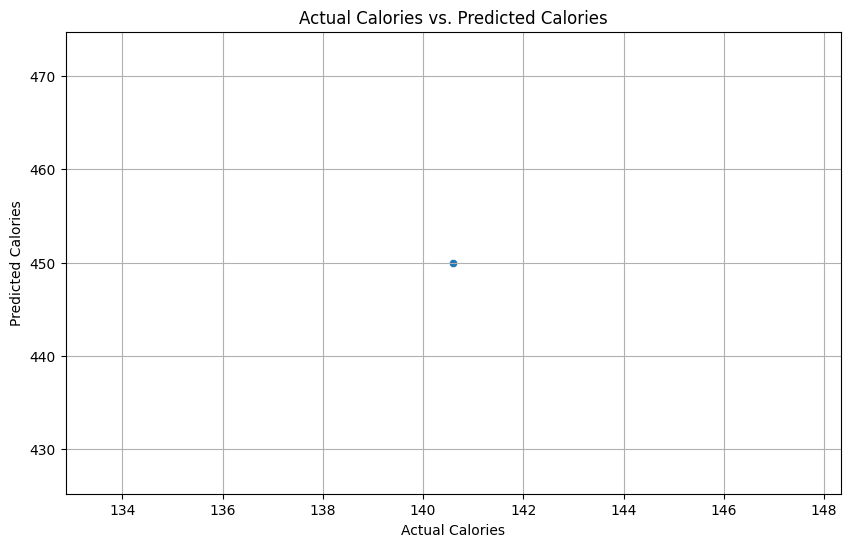

In [ ]:
# Create a DataFrame for calorie predictions
predicted_calories_df = pd.DataFrame(calorie_predictions, columns=['Predicted_Calories'])

# Convert predicted calories to numeric, coercing errors to NaN
predicted_calories_df['Predicted_Calories'] = pd.to_numeric(predicted_calories_df['Predicted_Calories'], errors='coerce')

# Combine the actual calories and predicted calories for comparison
# Assuming image_calorie_df and predicted_calories_df are aligned by index
comparison_df = pd.concat([image_calorie_df.reset_index(drop=True), predicted_calories_df], axis=1)

# Drop rows where predicted calories are NaN (due to errors or 'No URL')
comparison_df.dropna(subset=['Predicted_Calories'], inplace=True)

# Display the first few rows of the comparison DataFrame
display(comparison_df.head())

# Calculate a comparison metric, for example, the Mean Absolute Error
# Only consider predictions that are valid numbers.
mae = (comparison_df['Calories'] - comparison_df['Predicted_Calories']).abs().mean()
print(f"\nMean Absolute Error between Actual and Predicted Calories: {mae:.2f}")

# Optionally, visualize the comparison
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Calories', y='Predicted_Calories', data=comparison_df)
plt.title('Actual Calories vs. Predicted Calories')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.grid(True)
plt.show()

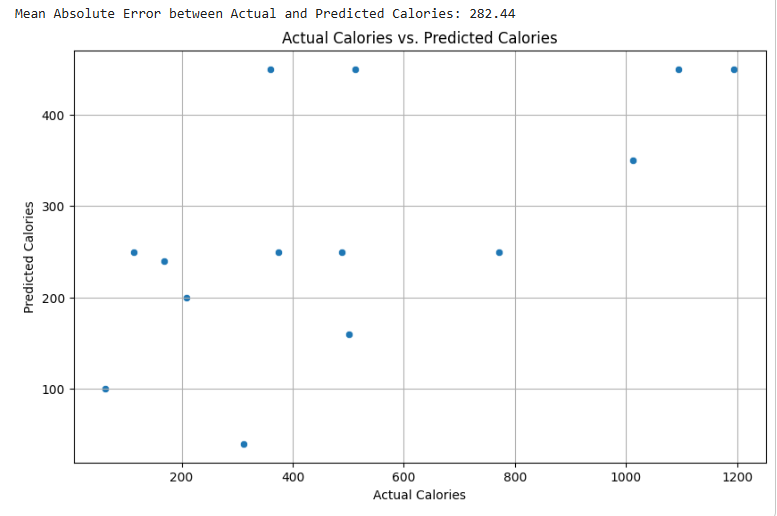